#DC - Breast Cancer Prediction

First few rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Missing values per column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dim

/tmp/ipykernel_2170/3223230046.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


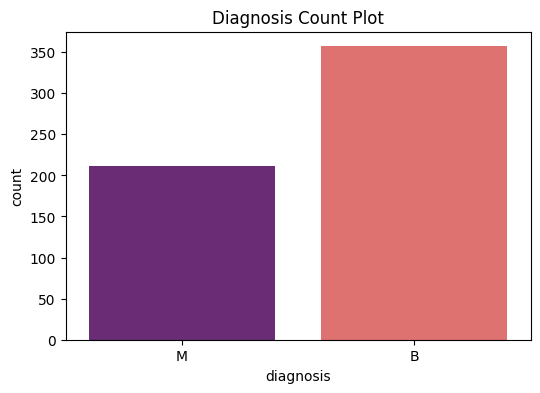


Counts of unique rows in diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64
Logistic Regression Accuracy: 0.9737
KNN Accuracy: 0.9474
Random Forest Accuracy: 0.9649
SVM Accuracy: 0.9737

The best model is: Logistic Regression with an accuracy of 0.9737


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Exploratory Data Analysis
# Load the dataset
df = pd.read_csv('/content/data (1).csv')
print("First few rows:")
display(df.head())

# Check and handle missing values
print("\nMissing values per column:")
print(df.isnull().sum())
# Drop columns that are completely empty (often 'Unnamed: 32' in this dataset) or unnecessary
df = df.dropna(axis=1, how='all')
df = df.drop(columns=['id'], errors='ignore')

# Create a Countplot to display diagnosis
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title('Diagnosis Count Plot')
plt.show()

# 2. Data Preprocessing
# Counts of unique rows in the ‘diagnosis’ column
print("\nCounts of unique rows in diagnosis:")
print(df['diagnosis'].value_counts())

# Map categorical values to numerical values
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis']) # M -> 1, B -> 0

# Splitting the data into train and test
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Scaling data for better performance in KNN and SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Building Models and Evaluation
results = {}

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
results['Logistic Regression'] = lr_acc
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# K Nearest Neighbours
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))
results['KNN'] = knn_acc
print(f"KNN Accuracy: {knn_acc:.4f}")

# Random Forests
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
results['Random Forest'] = rf_acc
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
results['SVM'] = svm_acc
print(f"SVM Accuracy: {svm_acc:.4f}")

# Which is the best model?
best_model = max(results, key=results.get)
print(f"\nThe best model is: {best_model} with an accuracy of {results[best_model]:.4f}")